In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
df=pd.read_csv("sensor.csv")
df.tail()

,time_ms,AQI_like,vNode_V,est_AO_V,DO,Temp_C,RH_pct
284,333110399,46,0.097,0.145,1,21.3,52.5
285,333112505,52,0.102,0.153,1,21.3,52.5
286,333114611,46,0.097,0.145,1,21.3,52.7
287,333116717,42,0.093,0.139,1,21.2,52.7
288,333118823,53,0.102,0.154,1,21.2,52.8


In [5]:
depend=["time_ms","vNode_V","est_AO_V"]


X=df[depend]
Y=df["Temp_C"]


In [6]:
X_train,X_test,y_train,y_test=train_test_split(
X,Y,test_size=0.2,random_state=0
)

y_test.head()

55     21.4
182    25.7
92     29.7
209    24.0
261    21.9
Name: Temp_C, dtype: float64

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=0,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred_rf = rf_model.predict(X_test)

In [11]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

In [12]:

print("Random Forest MAE:", mae_rf)
print("Random Forest MSE:", mse_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 0.07406034482759437
Random Forest MSE: 0.012530375000000588
Random Forest RMSE: 0.11193915758125299
Random Forest R2: 0.9991239293838414


In [15]:
 
from sklearn.ensemble import IsolationForest
import numpy as np


residuals = np.abs(y_test - y_pred_rf)


iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly_labels = iso_forest.fit_predict(
    residuals.values.reshape(-1, 1)
)

anomalies = anomaly_labels == -1




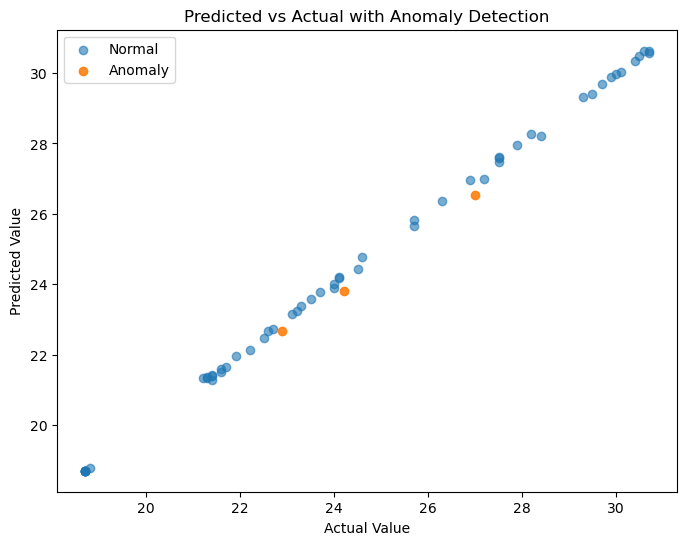

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Normal points
plt.scatter(
    y_test[~anomalies],
    y_pred_rf[~anomalies],
    label="Normal",
    alpha=0.6
)

# Anomalies
plt.scatter(
    y_test[anomalies],
    y_pred_rf[anomalies],
    label="Anomaly",
    alpha=0.9
)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Predicted vs Actual with Anomaly Detection")
plt.legend()
plt.show()


In [19]:
#  Here  is the summary 

#here we are using random forest  to train our model and ig we are getting the case of overfitting because the data given to us was very small 

# though other parameters such as MSE have shown improvements compare to linear regression model